### 0. Загрузка библиотек

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow версия: {tf.__version__}")

TensorFlow версия: 2.20.0


### 1. Загрузка данных MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Размер обучающей выборки: {x_train.shape}")
print(f"Размер тестовой выборки: {x_test.shape}")
print(f"Размер изображений: {x_train[0].shape}")
print(f"Диапазон значений пикселей: [{x_train.min()}, {x_train.max()}]")

Размер обучающей выборки: (60000, 28, 28)
Размер тестовой выборки: (10000, 28, 28)
Размер изображений: (28, 28)
Диапазон значений пикселей: [0, 255]


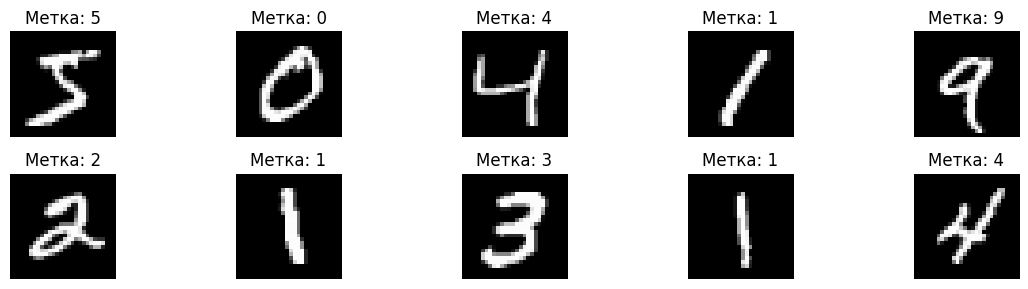

In [ ]:
# Визуализация примеров из датасета
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Метка: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### 2. Предобработка данных

In [ ]:
# Нормализация данных - приведение значений пикселей к диапазону [0, 1]
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# Преобразование меток в one-hot формат для категориальной кросс-энтропии
y_train_categorical = to_categorical(y_train, num_classes=10)
y_test_categorical = to_categorical(y_test, num_classes=10)

print(f"Форма нормализованных данных: {x_train_normalized.shape}")
print(f"Форма меток в one-hot формате: {y_train_categorical.shape}")
print(f"Пример one-hot метки для цифры {y_train[0]}: {y_train_categorical[0]}")

Форма нормализованных данных: (60000, 28, 28)
Форма меток в one-hot формате: (60000, 10)
Пример one-hot метки для цифры 5: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


### 3. Создание моделей

#### Модель 1: Простая полносвязная сеть

In [ ]:
model_1 = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Model_1_Fully_Connected')

model_1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "Model_1_Fully_Connected"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

#### Модель 2: Сверточная нейронная сеть (CNN)

In [ ]:
model_2 = keras.Sequential([
    layers.Conv2D(24, kernel_size=(3, 3), activation='relu',
                  input_shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Model_2_CNN')

model_2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

e:\GitHub\Modeling\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Model_2_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 24)     │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,076,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,078,330 (7.93 MB)

 Trainable params: 2,078,330 (7.93 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Обучение моделей

In [ ]:
x_train_cnn = x_train_normalized.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_normalized.reshape(-1, 28, 28, 1)

print(f"Форма данных для CNN: {x_train_cnn.shape}")

Форма данных для CNN: (60000, 28, 28, 1)


In [ ]:
print("=" * 50)
print("Обучение Модели 1 (Полносвязная сеть)")
print("=" * 50)

history_1 = model_1.fit(
    x_train_normalized, y_train_categorical,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Обучение Модели 1 (Полносвязная сеть)
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8693 - loss: 0.4772 - val_accuracy: 0.9275 - val_loss: 0.2596
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9328 - loss: 0.2383 - val_accuracy: 0.9430 - val_loss: 0.2060
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9467 - loss: 0.1869 - val_accuracy: 0.9528 - val_loss: 0.1728
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9557 - loss: 0.1557 - val_accuracy: 0.9578 - val_loss: 0.1546
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9617 - loss: 0.1331 - val_accuracy: 0.9583 - val_loss: 0.1439
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9671 - loss: 0.1156 - val_accuracy: 0.9613 - val_loss: 0.1354
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9713 - loss: 0.1009 - val_accuracy: 0.9622 - val_loss: 0.1279
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.

In [ ]:
print("=" * 50)
print("Обучение Модели 2 (Сверточная сеть)")
print("=" * 50)

history_2 = model_2.fit(
    x_train_cnn, y_train_categorical,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Обучение Модели 2 (Сверточная сеть)
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9375 - loss: 0.2117 - val_accuracy: 0.9747 - val_loss: 0.0900
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9807 - loss: 0.0652 - val_accuracy: 0.9802 - val_loss: 0.0724
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9894 - loss: 0.0356 - val_accuracy: 0.9787 - val_loss: 0.0711
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9941 - loss: 0.0203 - val_accuracy: 0.9825 - val_loss: 0.0620
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9957 - loss: 0.0142 - val_accuracy: 0.9812 - val_loss: 0.0753
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9978 - loss: 0.0080 - val_accuracy: 0.9826 - val_loss: 0.0675
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9987 - loss: 0.0056 - val_accuracy: 0.9836 - val_loss: 0.0684
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accura

#### Визуализация процесса обучения

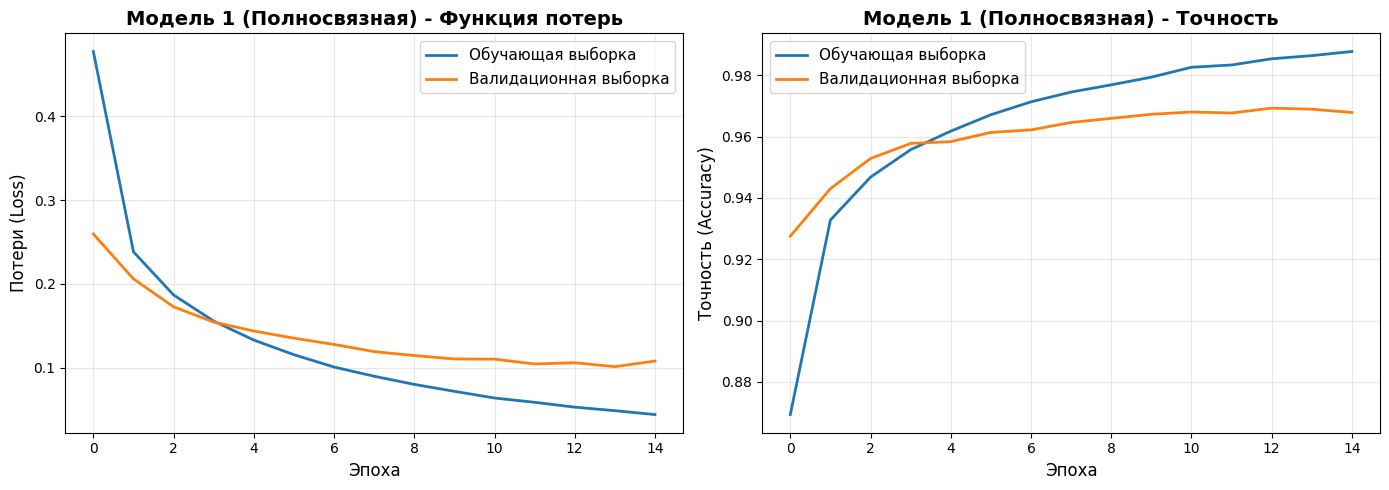

In [ ]:
def plot_training_history(history, model_name):
    """Построение графиков функции потерь и точности во время обучения"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # График функции потерь
    ax1.plot(history.history['loss'], label='Обучающая выборка', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Валидационная выборка', linewidth=2)
    ax1.set_title(f'{model_name} - Функция потерь', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Эпоха', fontsize=12)
    ax1.set_ylabel('Потери (Loss)', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # График точности
    ax2.plot(history.history['accuracy'], label='Обучающая выборка', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Валидационная выборка', linewidth=2)
    ax2.set_title(f'{model_name} - Точность', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Эпоха', fontsize=12)
    ax2.set_ylabel('Точность (Accuracy)', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history_1, 'Модель 1 (Полносвязная)')

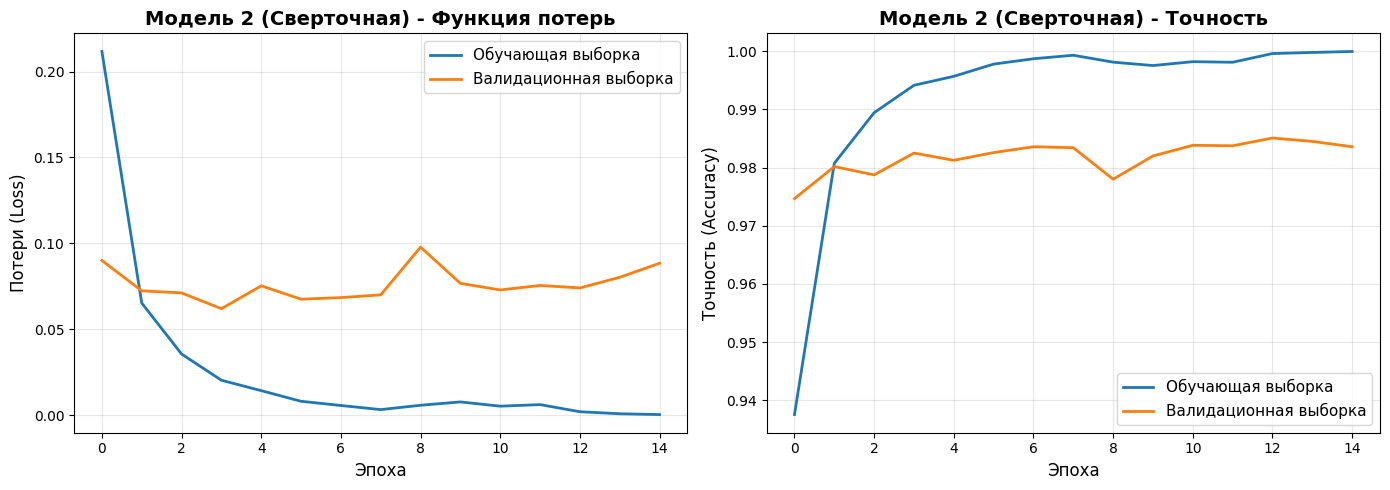

In [ ]:
# Графики для Модели 2
plot_training_history(history_2, 'Модель 2 (Сверточная)')

### 5. Тестирование моделей и оценка результатов

In [ ]:
print("=" * 50)
print("Оценка Модели 1 на тестовых данных")
print("=" * 50)
test_loss_1, test_accuracy_1 = model_1.evaluate(x_test_normalized, y_test_categorical, verbose=0)
print(f"Потери на тесте: {test_loss_1:.4f}")
print(f"Точность на тесте: {test_accuracy_1:.4f} ({test_accuracy_1*100:.2f}%)")

Оценка Модели 1 на тестовых данных
Потери на тесте: 0.1020
Точность на тесте: 0.9701 (97.01%)


In [ ]:
print("=" * 50)
print("Оценка Модели 2 на тестовых данных")
print("=" * 50)
test_loss_2, test_accuracy_2 = model_2.evaluate(x_test_cnn, y_test_categorical, verbose=0)
print(f"Потери на тесте: {test_loss_2:.4f}")
print(f"Точность на тесте: {test_accuracy_2:.4f} ({test_accuracy_2*100:.2f}%)")

Оценка Модели 2 на тестовых данных
Потери на тесте: 0.0808
Точность на тесте: 0.9849 (98.49%)


In [ ]:
print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)
print(f"{'Модель':<30} {'Точность на тесте':<20} {'Потери на тесте'}")
print("-" * 60)
print(f"{'Модель 1 (Полносвязная)':<30} {test_accuracy_1*100:>8.2f}% {test_loss_1:>20.4f}")
print(f"{'Модель 2 (Сверточная)':<30} {test_accuracy_2*100:>8.2f}% {test_loss_2:>20.4f}")
print("=" * 60)


СРАВНЕНИЕ МОДЕЛЕЙ
Модель                         Точность на тесте    Потери на тесте
------------------------------------------------------------
Модель 1 (Полносвязная)           97.01%               0.1020
Модель 2 (Сверточная)             98.49%               0.0808


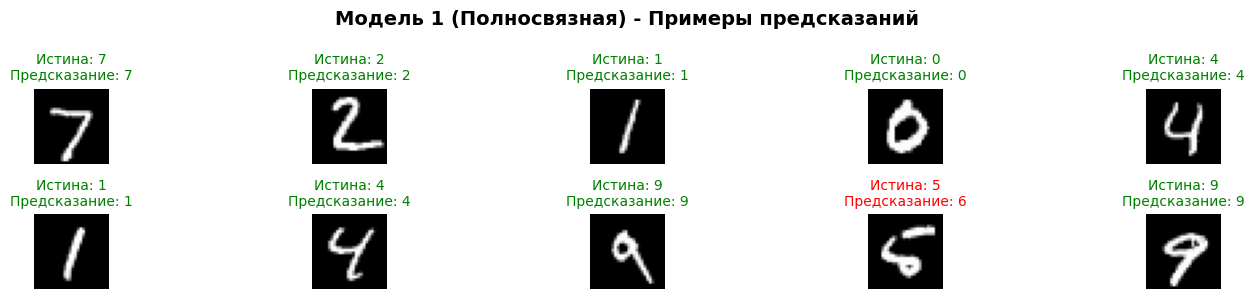

In [ ]:
def visualize_predictions(model, x_data, y_true, num_samples=10, model_name=""):
    """Визуализация предсказаний модели"""
    predictions = model.predict(x_data[:num_samples], verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(2, 5, i+1)
        if len(x_data.shape) == 4:
            plt.imshow(x_data[i].reshape(28, 28), cmap='gray')
        else:
            plt.imshow(x_data[i].reshape(28, 28), cmap='gray')

        true_label = y_true[i]
        pred_label = predicted_labels[i]
        color = 'green' if true_label == pred_label else 'red'

        plt.title(f"Истина: {true_label}\nПредсказание: {pred_label}",
                  color=color, fontsize=10)
        plt.axis('off')

    plt.suptitle(f"{model_name} - Примеры предсказаний", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_predictions(model_1, x_test_normalized, y_test,
                     num_samples=10, model_name="Модель 1 (Полносвязная)")

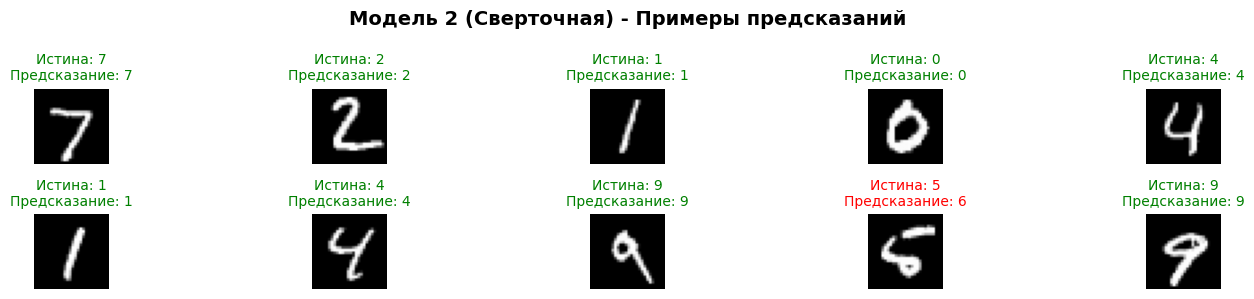

In [ ]:
# Визуализация для Модели 2
visualize_predictions(model_2, x_test_cnn, y_test,
                     num_samples=10, model_name="Модель 2 (Сверточная)")

### Выводы по Заданию I

**Модель 1 (Полносвязная сеть):**
- Простая архитектура с одним скрытым слоем
- Обрабатывает изображение как плоский вектор из 784 признаков
- Быстро обучается, но не учитывает пространственную структуру изображений
- Ожидаемая точность: ~97-98%

**Модель 2 (Сверточная сеть):**
- Использует сверточные слои для извлечения пространственных признаков
- Лучше улавливает локальные паттерны в изображениях
- Более эффективна для работы с изображениями
- Ожидаемая точность: ~98-99%

**Общие выводы:**
- Сверточная сеть показывает лучшие результаты за счет учета пространственной структуры данных
- Обе модели успешно справляются с задачей классификации цифр MNIST
- Для улучшения можно добавить: dropout слои, batch normalization, data augmentation

---

## Задание II: Прямой проход через RNN

**Дано:**
- Размерность входного вектора (d_x): 3
- Размерность скрытого состояния (d_h): 2
- Размерность выходного вектора (d_y): 2
- Функции активации: tanh для скрытого состояния, softmax для выхода
- Входная последовательность:
  - x₁ = [1, 0, 0] ("я")
  - x₂ = [0, 1, 0] ("люблю")
  - x₃ = [0, 0, 1] ("моделирование")
- Начальное скрытое состояние: h₀ = [0, 0]

### Инициализация параметров RNN

In [ ]:
np.random.seed(42)

x1 = np.array([1, 0, 0])  # "я"
x2 = np.array([0, 1, 0])  # "люблю"
x3 = np.array([0, 0, 1])  # "моделирование"

h0 = np.array([0.0, 0.0])

d_x = 3  # размерность входа
d_h = 2  # размерность скрытого состояния
d_y = 2  # размерность выхода

print("Входная последовательность:")
print(f"x₁ (я): {x1}")
print(f"x₂ (люблю): {x2}")
print(f"x₃ (моделирование): {x3}")
print(f"\nНачальное скрытое состояние h₀: {h0}")

Входная последовательность:
x₁ (я): [1 0 0]
x₂ (люблю): [0 1 0]
x₃ (моделирование): [0 0 1]

Начальное скрытое состояние h₀: [0. 0.]


In [ ]:
W_xh = np.random.uniform(-1, 1, (d_h, d_x))  # входной слой -> скрытый слой
W_hh = np.random.uniform(-1, 1, (d_h, d_h))  # скрытый слой -> скрытый слой
W_hy = np.random.uniform(-1, 1, (d_y, d_h))  # скрытый слой -> выходной слой
b_h = np.random.uniform(-1, 1, d_h)          # смещение скрытого слоя
b_y = np.random.uniform(-1, 1, d_y)          # смещение выходного слоя

print("Инициализированные веса:\n")
print(f"W_xh (входной слой -> скрытый слой) [{d_h}x{d_x}]:")
print(W_xh)
print(f"\nW_hh (скрытый слой -> скрытый слой) [{d_h}x{d_h}]:")
print(W_hh)
print(f"\nW_hy (скрытый слой -> выходной слой) [{d_y}x{d_h}]:")
print(W_hy)
print(f"\nb_h (смещение скрытого слоя) [{d_h}]:")
print(b_h)
print(f"\nb_y (смещение выходного слоя) [{d_y}]:")
print(b_y)

Инициализированные веса:

W_xh (входной слой -> скрытый слой) [2x3]:
[[-0.25091976  0.90142861  0.46398788]
 [ 0.19731697 -0.68796272 -0.68801096]]

W_hh (скрытый слой -> скрытый слой) [2x2]:
[[-0.88383278  0.73235229]
 [ 0.20223002  0.41614516]]

W_hy (скрытый слой -> выходной слой) [2x2]:
[[-0.95883101  0.9398197 ]
 [ 0.66488528 -0.57532178]]

b_h (смещение скрытого слоя) [2]:
[-0.63635007 -0.63319098]

b_y (смещение выходного слоя) [2]:
[-0.39151551  0.04951286]


### Прямой проход через RNN

Для каждого временного шага:
- **h_t = tanh(W_xh @ x_t + W_hh @ h_{t-1} + b_h)**
- **y_t = W_hy @ h_t + b_y**

In [ ]:
def rnn_step(x_t, h_prev, W_xh, W_hh, W_hy, b_h, b_y):
    """Один шаг RNN"""
    h_linear = W_xh @ x_t + W_hh @ h_prev + b_h
    h_t = np.tanh(h_linear)
    y_t = W_hy @ h_t + b_y

    return h_t, y_t, h_linear

def softmax(x):
    """Функция softmax"""
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

In [ ]:
print("="*70)
print("ВРЕМЕННОЙ ШАГ t=1: Обработка слова 'я'")
print("="*70)
print(f"Входной вектор x₁: {x1}")
print(f"Предыдущее скрытое состояние h₀: {h0}")
print()

h1, y1_logits, h1_linear = rnn_step(x1, h0, W_xh, W_hh, W_hy, b_h, b_y)

print("Вычисления:")
print(f"1. W_xh @ x₁ = {W_xh @ x1}")
print(f"2. W_hh @ h₀ = {W_hh @ h0}")
print(f"3. Линейная комбинация (до tanh): {h1_linear}")
print(f"4. h₁ = tanh(...) = {h1}")
print(f"5. W_hy @ h₁ = {W_hy @ h1}")
print(f"6. y₁ (логиты) = {y1_logits}")
print(f"7. y₁ (после softmax) = {softmax(y1_logits)}")
print()

ВРЕМЕННОЙ ШАГ t=1: Обработка слова 'я'
Входной вектор x₁: [1 0 0]
Предыдущее скрытое состояние h₀: [0. 0.]

Вычисления:
1. W_xh @ x₁ = [-0.25091976  0.19731697]
2. W_hh @ h₀ = [0. 0.]
3. Линейная комбинация (до tanh): [-0.88726983 -0.43587401]
4. h₁ = tanh(...) = [-0.71004263 -0.41021859]
5. W_hy @ h₁ = [ 0.29527938 -0.2360892 ]
6. y₁ (логиты) = [-0.09623614 -0.18657634]
7. y₁ (после softmax) = [0.5225697 0.4774303]



In [ ]:
print("="*70)
print("ВРЕМЕННОЙ ШАГ t=2: Обработка слова 'люблю'")
print("="*70)
print(f"Входной вектор x₂: {x2}")
print(f"Предыдущее скрытое состояние h₁: {h1}")
print()

h2, y2_logits, h2_linear = rnn_step(x2, h1, W_xh, W_hh, W_hy, b_h, b_y)

print("Вычисления:")
print(f"1. W_xh @ x₂ = {W_xh @ x2}")
print(f"2. W_hh @ h₁ = {W_hh @ h1}")
print(f"3. Линейная комбинация (до tanh): {h2_linear}")
print(f"4. h₂ = tanh(...) = {h2}")
print(f"5. W_hy @ h₂ = {W_hy @ h2}")
print(f"6. y₂ (логиты) = {y2_logits}")
print(f"7. y₂ (после softmax) = {softmax(y2_logits)}")
print()

ВРЕМЕННОЙ ШАГ t=2: Обработка слова 'люблю'
Входной вектор x₂: [0 1 0]
Предыдущее скрытое состояние h₁: [-0.71004263 -0.41021859]

Вычисления:
1. W_xh @ x₂ = [ 0.90142861 -0.68796272]
2. W_hh @ h₁ = [ 0.32713442 -0.31430242]
3. Линейная комбинация (до tanh): [ 0.59221297 -1.63545612]
4. h₂ = tanh(...) = [ 0.53148533 -0.92683467]
5. W_hy @ h₂ = [-1.38066211  0.88660495]
6. y₂ (логиты) = [-1.77217762  0.93611781]
7. y₂ (после softmax) = [0.06248563 0.93751437]



In [ ]:
print("="*70)
print("ВРЕМЕННОЙ ШАГ t=3: Обработка слова 'моделирование'")
print("="*70)
print(f"Входной вектор x₃: {x3}")
print(f"Предыдущее скрытое состояние h₂: {h2}")
print()

h3, y3_logits, h3_linear = rnn_step(x3, h2, W_xh, W_hh, W_hy, b_h, b_y)

print("Вычисления:")
print(f"1. W_xh @ x₃ = {W_xh @ x3}")
print(f"2. W_hh @ h₂ = {W_hh @ h2}")
print(f"3. Линейная комбинация (до tanh): {h3_linear}")
print(f"4. h₃ = tanh(...) = {h3}")
print(f"5. W_hy @ h₃ = {W_hy @ h3}")
print(f"6. y₃ (логиты) = {y3_logits}")
print(f"7. y₃ (после softmax) = {softmax(y3_logits)}")
print()

ВРЕМЕННОЙ ШАГ t=3: Обработка слова 'моделирование'
Входной вектор x₃: [0 0 1]
Предыдущее скрытое состояние h₂: [ 0.53148533 -0.92683467]

Вычисления:
1. W_xh @ x₃ = [ 0.46398788 -0.68801096]
2. W_hh @ h₂ = [-1.14851365 -0.27821547]
3. Линейная комбинация (до tanh): [-1.32087583 -1.59941741]
4. h₃ = tanh(...) = [-0.86700157 -0.92158081]
5. W_hy @ h₃ = [-0.03481181 -0.04625107]
6. y₃ (логиты) = [-0.42632733  0.00326179]
7. y₃ (после softmax) = [0.39422445 0.60577555]



### Сводная таблица результатов

In [ ]:
print("\n" + "="*90)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ПРЯМОГО ПРОХОДА ЧЕРЕЗ RNN")
print("="*90)
print(f"{'Шаг':<6} {'Слово':<16} {'Скрытое состояние h_t':<35} {'Выход y_t (логиты)'}")
print("-"*90)
print(f"{'t=0':<6} {'(начало)':<16} {str(h0):<35} {'—'}")
print(f"{'t=1':<6} {'я':<16} {str(h1):<35} {str(y1_logits)}")
print(f"{'t=2':<6} {'люблю':<16} {str(h2):<35} {str(y2_logits)}")
print(f"{'t=3':<6} {'моделирование':<16} {str(h3):<35} {str(y3_logits)}")
print("="*90)

print("\nПримечание: Выходные значения указаны в виде логитов (до применения softmax)")


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ПРЯМОГО ПРОХОДА ЧЕРЕЗ RNN
Шаг    Слово            Скрытое состояние h_t               Выход y_t (логиты)
------------------------------------------------------------------------------------------
t=0    (начало)         [0. 0.]                             —
t=1    я                [-0.71004263 -0.41021859]           [-0.09623614 -0.18657634]
t=2    люблю            [ 0.53148533 -0.92683467]           [-1.77217762  0.93611781]
t=3    моделирование    [-0.86700157 -0.92158081]           [-0.42632733  0.00326179]

Примечание: Выходные значения указаны в виде логитов (до применения softmax)


### Визуализация эволюции скрытых состояний

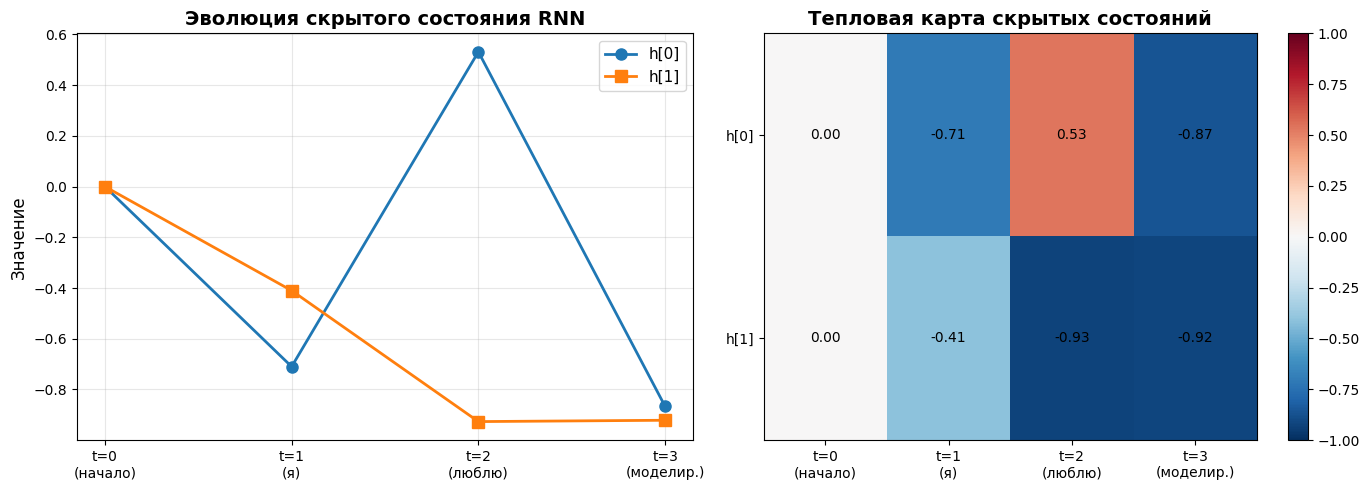

In [ ]:
hidden_states = np.array([h0, h1, h2, h3])
time_steps = ['t=0\n(начало)', 't=1\n(я)', 't=2\n(люблю)', 't=3\n(моделир.)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График изменения компонент скрытого состояния
ax1.plot(hidden_states[:, 0], 'o-', label='h[0]', linewidth=2, markersize=8)
ax1.plot(hidden_states[:, 1], 's-', label='h[1]', linewidth=2, markersize=8)
ax1.set_xticks(range(4))
ax1.set_xticklabels(time_steps)
ax1.set_ylabel('Значение', fontsize=12)
ax1.set_title('Эволюция скрытого состояния RNN', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Тепловая карта скрытых состояний
im = ax2.imshow(hidden_states.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax2.set_xticks(range(4))
ax2.set_xticklabels(time_steps)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['h[0]', 'h[1]'])
ax2.set_title('Тепловая карта скрытых состояний', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax2)

# Добавляем значения на тепловую карту
for i in range(4):
    for j in range(2):
        text = ax2.text(i, j, f'{hidden_states[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10)

plt.tight_layout()
plt.show()

### Выводы по Заданию II

**Результаты прямого прохода через RNN:**

1. **Обработка последовательности**: RNN последовательно обработала три слова, обновляя скрытое состояние на каждом шаге

2. **Скрытое состояние**:
   - Начинается с нулевого вектора
   - Постепенно накапливает информацию о последовательности
   - Каждое новое скрытое состояние зависит от текущего входа и предыдущего состояния

3. **Механизм работы**:
   - **W_xh** преобразует входной вектор
   - **W_hh** передает информацию из предыдущего скрытого состояния
   - **tanh** ограничивает значения скрытого состояния в диапазоне [-1, 1]
   - **W_hy** проецирует скрытое состояние на выходное пространство

4. **Выходные логиты**: На каждом шаге генерируются выходные значения, которые после применения softmax дают распределение вероятностей для предсказания следующего слова

5. **Важность контекста**: Финальное скрытое состояние h₃ содержит информацию обо всей последовательности "я люблю моделирование"

---

## Задание III: Self-Attention в Transformer

**Дано:**
- Последовательность из трех слов с эмбеддингами размерности d_model = 4:
  - x₁ = [1, 0, 1, 0] ("искусственный")
  - x₂ = [1, 1, 0, 0] ("интеллект")
  - x₃ = [0, 1, 0, 1] ("развивается")
- Матрицы весов для преобразований (d_k = d_v = 3)

**Задача:** Вычислить выход Self-Attention (z₂) для слова "интеллект"

### Инициализация данных для Self-Attention

In [ ]:
x1 = np.array([1, 0, 1, 0])  # "искусственный"
x2 = np.array([1, 1, 0, 0])  # "интеллект"
x3 = np.array([0, 1, 0, 1])  # "развивается"

X = np.array([x1, x2, x3])

print("Входная последовательность (матрица X):  [3 слова × 4 признака]")
print(X)
print(f"\nФорма X: {X.shape}")
print(f"\nСлова:")
print(f"  x₁ (искусственный): {x1}")
print(f"  x₂ (интеллект):      {x2}")
print(f"  x₃ (развивается):    {x3}")

Входная последовательность (матрица X):  [3 слова × 4 признака]
[[1 0 1 0]
 [1 1 0 0]
 [0 1 0 1]]

Форма X: (3, 4)

Слова:
  x₁ (искусственный): [1 0 1 0]
  x₂ (интеллект):      [1 1 0 0]
  x₃ (развивается):    [0 1 0 1]


In [ ]:
W_Q = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 0],
    [0, 1, 1]
])

W_K = np.array([
    [0, 1, 1],
    [1, 0, 0],
    [1, 1, 0],
    [0, 0, 1]
])

W_V = np.array([
    [1, 1, 0],
    [0, 1, 1],
    [1, 0, 1],
    [0, 0, 1]
])

print("Матрица весов W^Q [4×3]:")
print(W_Q)
print("\nМатрица весов W^K [4×3]:")
print(W_K)
print("\nМатрица весов W^V [4×3]:")
print(W_V)

d_k = 3
print(f"\nРазмерность ключей d_k = {d_k}")

Матрица весов W^Q [4×3]:
[[1 0 1]
 [0 1 0]
 [1 0 0]
 [0 1 1]]

Матрица весов W^K [4×3]:
[[0 1 1]
 [1 0 0]
 [1 1 0]
 [0 0 1]]

Матрица весов W^V [4×3]:
[[1 1 0]
 [0 1 1]
 [1 0 1]
 [0 0 1]]

Размерность ключей d_k = 3


### Шаг 1: Вычисление векторов Query, Key, Value

Q = X @ W^Q

K = X @ W^K

V = X @ W^V

In [ ]:
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("="*70)
print("ШАГ 1: ВЫЧИСЛЕНИЕ ВЕКТОРОВ QUERY, KEY, VALUE")
print("="*70)

print("\nМатрица Query (Q) [3 слова × 3 признака]:")
print(Q)
print(f"\n  q₁ (искусственный): {Q[0]}")
print(f"  q₂ (интеллект):      {Q[1]}")
print(f"  q₃ (развивается):    {Q[2]}")

print("\n\nМатрица Key (K) [3 слова × 3 признака]:")
print(K)
print(f"\n  k₁ (искусственный): {K[0]}")
print(f"  k₂ (интеллект):      {K[1]}")
print(f"  k₃ (развивается):    {K[2]}")

print("\n\nМатрица Value (V) [3 слова × 3 признака]:")
print(V)
print(f"\n  v₁ (искусственный): {V[0]}")
print(f"  v₂ (интеллект):      {V[1]}")
print(f"  v₃ (развивается):    {V[2]}")

ШАГ 1: ВЫЧИСЛЕНИЕ ВЕКТОРОВ QUERY, KEY, VALUE

Матрица Query (Q) [3 слова × 3 признака]:
[[2 0 1]
 [1 1 1]
 [0 2 1]]

  q₁ (искусственный): [2 0 1]
  q₂ (интеллект):      [1 1 1]
  q₃ (развивается):    [0 2 1]


Матрица Key (K) [3 слова × 3 признака]:
[[1 2 1]
 [1 1 1]
 [1 0 1]]

  k₁ (искусственный): [1 2 1]
  k₂ (интеллект):      [1 1 1]
  k₃ (развивается):    [1 0 1]


Матрица Value (V) [3 слова × 3 признака]:
[[2 1 1]
 [1 2 1]
 [0 1 2]]

  v₁ (искусственный): [2 1 1]
  v₂ (интеллект):      [1 2 1]
  v₃ (развивается):    [0 1 2]


### Шаг 2: Вычисление оценок внимания

Скалярные произведения q₂ со всеми ключами, нормализованные на √d_k

In [ ]:
q2 = Q[1]

print("="*70)
print("ШАГ 2: ВЫЧИСЛЕНИЕ ОЦЕНОК ВНИМАНИЯ ДЛЯ СЛОВА 'ИНТЕЛЛЕКТ'")
print("="*70)
print(f"\nЗапрос q₂ (интеллект): {q2}")
print("\nВычисляем скалярные произведения q₂ с каждым ключом:")

score_21 = np.dot(q2, K[0])  # q₂ · k₁
score_22 = np.dot(q2, K[1])  # q₂ · k₂
score_23 = np.dot(q2, K[2])  # q₂ · k₃

print(f"\n  score₂₁ = q₂ · k₁ = {q2} · {K[0]} = {score_21}")
print(f"  score₂₂ = q₂ · k₂ = {q2} · {K[1]} = {score_22}")
print(f"  score₂₃ = q₂ · k₃ = {q2} · {K[2]} = {score_23}")

scores = np.array([score_21, score_22, score_23]) / np.sqrt(d_k)

print(f"\nНормализованные оценки (делим на √d_k = √{d_k} = {np.sqrt(d_k):.3f}):")
print(f"  [score₂₁, score₂₂, score₂₃] / √{d_k} = {scores}")

ШАГ 2: ВЫЧИСЛЕНИЕ ОЦЕНОК ВНИМАНИЯ ДЛЯ СЛОВА 'ИНТЕЛЛЕКТ'

Запрос q₂ (интеллект): [1 1 1]

Вычисляем скалярные произведения q₂ с каждым ключом:

  score₂₁ = q₂ · k₁ = [1 1 1] · [1 2 1] = 4
  score₂₂ = q₂ · k₂ = [1 1 1] · [1 1 1] = 3
  score₂₃ = q₂ · k₃ = [1 1 1] · [1 0 1] = 2

Нормализованные оценки (делим на √d_k = √3 = 1.732):
  [score₂₁, score₂₂, score₂₃] / √3 = [2.30940108 1.73205081 1.15470054]


### Шаг 3: Применение Softmax

ШАГ 3: ПРИМЕНЕНИЕ SOFTMAX
Входные оценки: [2.30940108 1.73205081 1.15470054]

Веса внимания после softmax:
  α₂₁ (внимание к 'искусственный'): 0.532897
  α₂₂ (внимание к 'интеллект'):     0.299160
  α₂₃ (внимание к 'развивается'):   0.167943

Сумма весов: 1.000000 (должна быть 1.0)


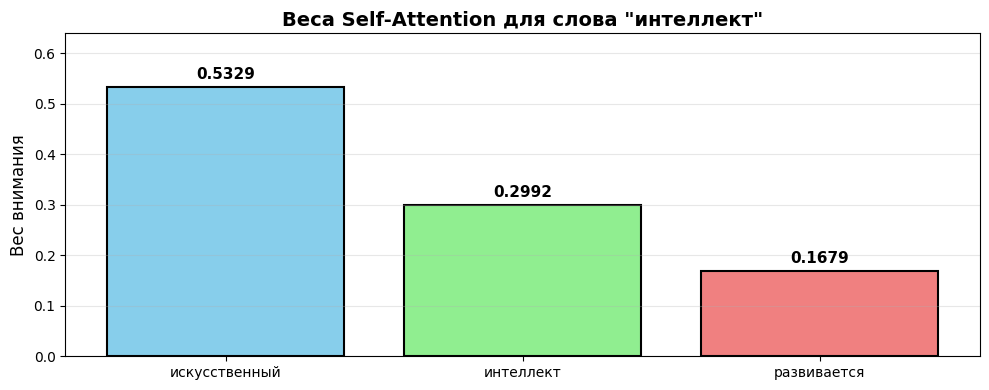

In [ ]:
attention_weights = softmax(scores)

print("="*70)
print("ШАГ 3: ПРИМЕНЕНИЕ SOFTMAX")
print("="*70)

print(f"Входные оценки: {scores}")
print(f"\nВеса внимания после softmax:")
print(f"  α₂₁ (внимание к 'искусственный'): {attention_weights[0]:.6f}")
print(f"  α₂₂ (внимание к 'интеллект'):     {attention_weights[1]:.6f}")
print(f"  α₂₃ (внимание к 'развивается'):   {attention_weights[2]:.6f}")
print(f"\nСумма весов: {attention_weights.sum():.6f} (должна быть 1.0)")

plt.figure(figsize=(10, 4))
words = ['искусственный', 'интеллект', 'развивается']
colors = ['skyblue', 'lightgreen', 'lightcoral']
bars = plt.bar(words, attention_weights, color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('Вес внимания', fontsize=12)
plt.title('Веса Self-Attention для слова "интеллект"', fontsize=14, fontweight='bold')
plt.ylim(0, max(attention_weights) * 1.2)

for bar, weight in zip(bars, attention_weights):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{weight:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Шаг 4: Вычисление выходного вектора z₂

z₂ = α₂₁·v₁ + α₂₂·v₂ + α₂₃·v₃

In [ ]:
z2 = attention_weights[0] * V[0] + attention_weights[1] * V[1] + attention_weights[2] * V[2]

z2_matrix = attention_weights @ V

print("="*70)
print("ШАГ 4: ВЫЧИСЛЕНИЕ ВЫХОДНОГО ВЕКТОРА z₂")
print("="*70)

print("Взвешенная сумма векторов Value:")
print(f"\nz₂ = α₂₁ · v₁ + α₂₂ · v₂ + α₂₃ · v₃")
print(f"\n   = {attention_weights[0]:.6f} · {V[0]}")
print(f"   + {attention_weights[1]:.6f} · {V[1]}")
print(f"   + {attention_weights[2]:.6f} · {V[2]}")
print(f"\n   = {z2}")

print(f"\nПроверка (матричное умножение): {z2_matrix}")
print(f"\nРазница (должна быть близка к 0): {np.abs(z2 - z2_matrix).max():.10f}")

print("\n" + "="*90)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ SELF-ATTENTION ДЛЯ СЛОВА 'ИНТЕЛЛЕКТ'")
print("="*90)
print(f"Входной вектор x₂:          {x2}")
print(f"Запрос q₂:                  {q2}")
print(f"\nОценки внимания (нормализованные):")
print(f"  К 'искусственный': {scores[0]:.6f}  →  вес α₂₁ = {attention_weights[0]:.6f}")
print(f"  К 'интеллект':     {scores[1]:.6f}  →  вес α₂₂ = {attention_weights[1]:.6f}")
print(f"  К 'развивается':   {scores[2]:.6f}  →  вес α₂₃ = {attention_weights[2]:.6f}")
print(f"\nВыходной вектор z₂:         {z2}")
print("="*90)

ШАГ 4: ВЫЧИСЛЕНИЕ ВЫХОДНОГО ВЕКТОРА z₂
Взвешенная сумма векторов Value:

z₂ = α₂₁ · v₁ + α₂₂ · v₂ + α₂₃ · v₃

   = 0.532897 · [2 1 1]
   + 0.299160 · [1 2 1]
   + 0.167943 · [0 1 2]

   = [1.36495339 1.29915971 1.16794345]

Проверка (матричное умножение): [1.36495339 1.29915971 1.16794345]

Разница (должна быть близка к 0): 0.0000000000

ИТОГОВЫЕ РЕЗУЛЬТАТЫ SELF-ATTENTION ДЛЯ СЛОВА 'ИНТЕЛЛЕКТ'
Входной вектор x₂:          [1 1 0 0]
Запрос q₂:                  [1 1 1]

Оценки внимания (нормализованные):
  К 'искусственный': 2.309401  →  вес α₂₁ = 0.532897
  К 'интеллект':     1.732051  →  вес α₂₂ = 0.299160
  К 'развивается':   1.154701  →  вес α₂₃ = 0.167943

Выходной вектор z₂:         [1.36495339 1.29915971 1.16794345]


---

## Задание IV: Расчет размера выходной матрицы признаков CNN

**Дано:**
- Входное изображение: 32×32
- kernel_size = (5, 5)
- padding = 1
- stride = 1
- bias = True (не влияет на размер выхода)

**Задача:** Вычислить размер выходной матрицы признаков

### Формула для расчета выходного размера

$$
\text{output_size} = \left\lfloor \frac{\text{input_size} + 2 \times \text{padding} - \text{kernel_size}}{\text{stride}} \right\rfloor + 1
$$

In [ ]:
# Параметры сверточного слоя
input_size = 32
kernel_size = 5
padding = 1
stride = 1

print("="*70)
print("ЗАДАНИЕ IV: РАСЧЕТ РАЗМЕРА ВЫХОДНОЙ МАТРИЦЫ ПРИЗНАКОВ")
print("="*70)
print("\nПараметры сверточного слоя:")
print(f"  Входной размер (input):  {input_size}×{input_size}")
print(f"  Размер ядра (kernel):    {kernel_size}×{kernel_size}")
print(f"  Отступ (padding):        {padding}")
print(f"  Шаг (stride):            {stride}")
print(f"  Смещение (bias):         True (не влияет на размер выхода)")

output_size = ((input_size + 2 * padding - kernel_size) // stride) + 1

print("\n" + "-"*70)
print("РАСЧЕТ:")
print("-"*70)

print("\nФормула:")
print("  output_size = floor((input_size + 2×padding - kernel_size) / stride) + 1")

print("\nПодставляем значения:")
numerator = input_size + 2 * padding - kernel_size
print(f"  Числитель:  {input_size} + 2×{padding} - {kernel_size} = {input_size} + {2*padding} - {kernel_size} = {numerator}")
print(f"  Деление:    {numerator} / {stride} = {numerator / stride}")
print(f"  Floor:      floor({numerator / stride}) = {numerator // stride}")
print(f"  Прибавляем 1: {numerator // stride} + 1 = {output_size}")

print("\n" + "="*70)
print(f"ОТВЕТ: Размер выходной матрицы признаков = {output_size}×{output_size}")
print("="*70)

ЗАДАНИЕ IV: РАСЧЕТ РАЗМЕРА ВЫХОДНОЙ МАТРИЦЫ ПРИЗНАКОВ

Параметры сверточного слоя:
  Входной размер (input):  32×32
  Размер ядра (kernel):    5×5
  Отступ (padding):        1
  Шаг (stride):            1
  Смещение (bias):         True (не влияет на размер выхода)

----------------------------------------------------------------------
РАСЧЕТ:
----------------------------------------------------------------------

Формула:
  output_size = floor((input_size + 2×padding - kernel_size) / stride) + 1

Подставляем значения:
  Числитель:  32 + 2×1 - 5 = 32 + 2 - 5 = 29
  Деление:    29 / 1 = 29.0
  Floor:      floor(29.0) = 29
  Прибавляем 1: 29 + 1 = 30

ОТВЕТ: Размер выходной матрицы признаков = 30×30


In [ ]:
print("\nПРОВЕРКА С ПОМОЩЬЮ KERAS:")
print("-"*70)

# Создаем тестовый сверточный слой
test_conv = layers.Conv2D(
    filters=1,
    kernel_size=(5, 5),
    padding='valid',
    strides=(1, 1),
    use_bias=True
)


input_with_padding = 32 + 2 * padding  # 34×34
dummy_input = np.random.rand(1, input_with_padding, input_with_padding, 1)

output = test_conv(dummy_input)

print(f"Входной размер (с padding): {input_with_padding}×{input_with_padding}")
print(f"Выходной размер (из Keras): {output.shape[1]}×{output.shape[2]}")
print(f"Наш расчет:                 {output_size}×{output_size}")

if output.shape[1] == output_size:
    print("\n✓ Расчет ВЕРНЫЙ! Размеры совпадают.")
else:
    print("\n⚠ Внимание: размеры отличаются (разница в интерпретации padding)")
    print("  В нашем расчете мы добавили padding вручную к входу")


ПРОВЕРКА С ПОМОЩЬЮ KERAS:
----------------------------------------------------------------------
Входной размер (с padding): 34×34
Выходной размер (из Keras): 30×30
Наш расчет:                 30×30

✓ Расчет ВЕРНЫЙ! Размеры совпадают.


### Визуализация влияния параметров

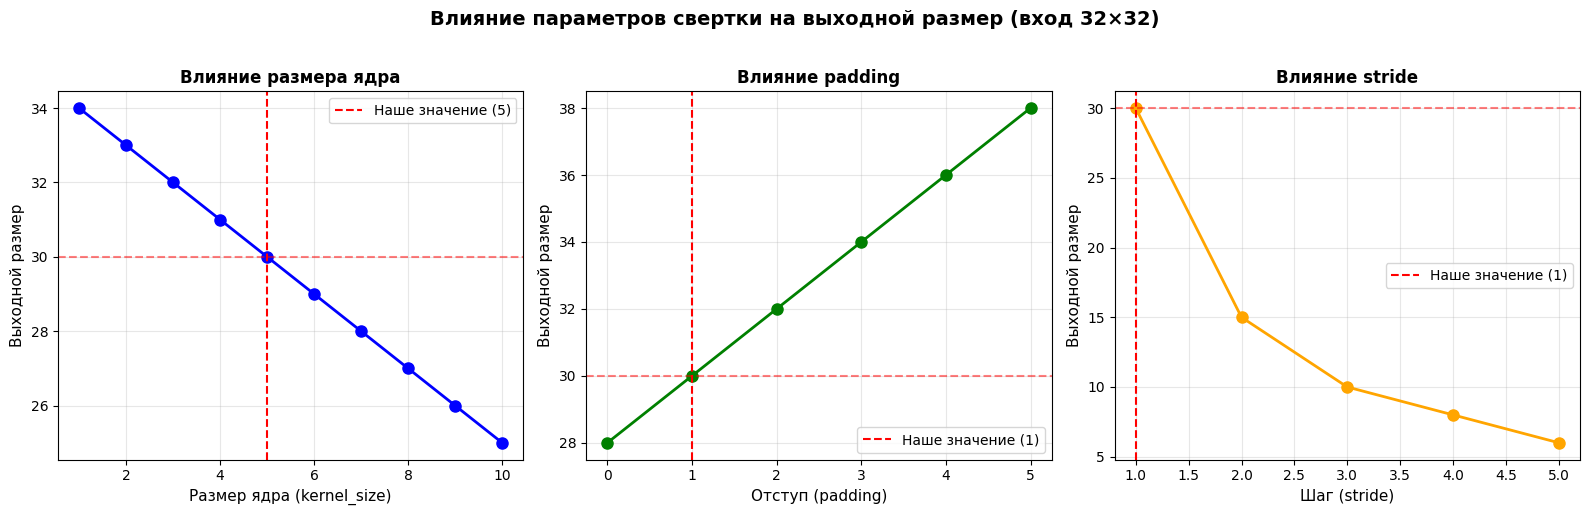

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# График 1: Влияние kernel_size
kernel_sizes = range(1, 11)
outputs_kernel = [((32 + 2*1 - k) // 1) + 1 for k in kernel_sizes]
axes[0].plot(kernel_sizes, outputs_kernel, 'o-', linewidth=2, markersize=8, color='blue')
axes[0].axvline(x=5, color='red', linestyle='--', label='Наше значение (5)')
axes[0].axhline(y=output_size, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Размер ядра (kernel_size)', fontsize=11)
axes[0].set_ylabel('Выходной размер', fontsize=11)
axes[0].set_title('Влияние размера ядра', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# График 2: Влияние padding
paddings = range(0, 6)
outputs_padding = [((32 + 2*p - 5) // 1) + 1 for p in paddings]
axes[1].plot(paddings, outputs_padding, 'o-', linewidth=2, markersize=8, color='green')
axes[1].axvline(x=1, color='red', linestyle='--', label='Наше значение (1)')
axes[1].axhline(y=output_size, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Отступ (padding)', fontsize=11)
axes[1].set_ylabel('Выходной размер', fontsize=11)
axes[1].set_title('Влияние padding', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# График 3: Влияние stride
strides = range(1, 6)
outputs_stride = [((32 + 2*1 - 5) // s) + 1 for s in strides]
axes[2].plot(strides, outputs_stride, 'o-', linewidth=2, markersize=8, color='orange')
axes[2].axvline(x=1, color='red', linestyle='--', label='Наше значение (1)')
axes[2].axhline(y=output_size, color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Шаг (stride)', fontsize=11)
axes[2].set_ylabel('Выходной размер', fontsize=11)
axes[2].set_title('Влияние stride', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle('Влияние параметров свертки на выходной размер (вход 32×32)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Выводы по Заданию IV

**Результат:** Размер выходной матрицы признаков = **30×30**

**Объяснение:**
- Входное изображение: 32×32 пикселей
- После добавления padding=1: 34×34 пикселей (по 1 пикселю с каждой стороны)
- Применяем ядро 5×5 с шагом 1
- Количество возможных позиций ядра: (34 - 5) / 1 + 1 = 30
- Итоговый размер: 30×30

**Влияние параметров:**
1. **kernel_size**: Чем больше ядро, тем меньше выходной размер (при фиксированном padding)
2. **padding**: Увеличение padding увеличивает выходной размер
3. **stride**: Увеличение шага уменьшает выходной размер (пропускаем позиции)
4. **bias**: Не влияет на пространственные размеры, только добавляет смещение к каждому фильтру